In [23]:
#Loading libraries and dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Smart_City_Complaints.csv" , sep=';')
print(df.head())
print(df.info())
print(df.shape)

  Complaint_ID Complaint_Date Resolved_Date   Zone            Category  \
0    CMP100000     12-04-2024    22-04-2024  South         Road Damage   
1    CMP100001     11-03-2025    01-04-2025  North  Garbage Collection   
2    CMP100002     27-09-2024    02-10-2024  North       Public Safety   
3    CMP100003     16-04-2024           NaN   East       Public Safety   
4    CMP100004     12-03-2024    31-03-2024   East     Sewage Overflow   

          Department Priority    Status  Satisfaction_Score  \
0   Roads Department   Medium  Resolved                   3   
1         Sanitation      Low  Resolved                   3   
2  Safety Department   Medium  Resolved                   5   
3  Safety Department      Low      Open                   1   
4       Public Works   Medium  Resolved                   3   

                             Description  Resolution_Days  Severity_Score  
0      Potholes and road damage observed             10.0               2  
1      Garbage not colle

In [ ]:
#Handling missing values and removing duplicates
print(df.isnull().sum())
print("Duplicate Rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Dataset Shape After Removing Duplicates:")
print(df.shape)



Complaint_ID              0
Complaint_Date            0
Resolved_Date         10015
Zone                      0
Category                  0
Department                0
Priority                  0
Status                    0
Satisfaction_Score        0
Description               0
Resolution_Days       10015
Severity_Score            0
dtype: int64
Duplicate Rows: 0
Dataset Shape After Removing Duplicates:
(100000, 12)


In [ ]:
#Convert date columns into datetime format
df['Complaint_Date'] = pd.to_datetime(
    df['Complaint_Date'],
    format='%d-%m-%Y'
)

df['Resolved_Date'] = pd.to_datetime(
    df['Resolved_Date'],
    format='%d-%m-%Y',
    errors='coerce'
)
print(df[['Complaint_Date','Resolved_Date']].head())
print(df.dtypes)

  Complaint_Date Resolved_Date
0     2024-04-12    2024-04-22
1     2025-03-11    2025-04-01
2     2024-09-27    2024-10-02
3     2024-04-16           NaT
4     2024-03-12    2024-03-31
Complaint_ID                  object
Complaint_Date        datetime64[ns]
Resolved_Date         datetime64[ns]
Zone                          object
Category                      object
Department                    object
Priority                      object
Status                        object
Satisfaction_Score             int64
Description                   object
Resolution_Days              float64
Severity_Score                 int64
dtype: object


In [ ]:
#Clean complaint text descriptions
#Convert text to lowercase
df['Description'] = df['Description'].str.lower()
#Remove extra spaces
df['Description'] = df['Description'].str.strip()
#Remove special characters
df['Description'] = df['Description'].str.replace(
    '[^a-zA-Z0-9 ]',
    '',
    regex=True
)
print("After Cleaning:")
print(df['Description'].head())



After Cleaning:
0        potholes and road damage observed
1        garbage not collected in locality
2           public safety concern reported
3           public safety concern reported
4    sewage overflow causing inconvenience
Name: Description, dtype: object


In [ ]:
#Create derived variables
severity_map = {
    'Low': 1,
    'Medium': 2,
    'High': 3
}
df['Severity_Score'] = df['Priority'].map(severity_map)
print(df[['Priority', 'Severity_Score']].head())
df['Resolution_Delay'] = (
    df['Resolved_Date'] - df['Complaint_Date']
).dt.days

print(df[['Complaint_Date',
          'Resolved_Date',
          'Resolution_Delay']].head())


  Priority  Severity_Score
0   Medium               2
1      Low               1
2   Medium               2
3      Low               1
4   Medium               2
  Complaint_Date Resolved_Date  Resolution_Delay
0     2024-04-12    2024-04-22              10.0
1     2025-03-11    2025-04-01              21.0
2     2024-09-27    2024-10-02               5.0
3     2024-04-16           NaT               NaN
4     2024-03-12    2024-03-31              19.0


In [ ]:
#KPI design
total_complaints = len(df)
print("Total Complaints:", total_complaints)
resolved_complaints = df[df['Status'] == 'Resolved'].shape[0]
print("Resolved Complaints:", resolved_complaints)
resolution_rate = (
    resolved_complaints / total_complaints
) * 100
print("Resolution Rate: {:.2f}%".format(resolution_rate))
avg_resolution_time = df['Resolution_Delay'].mean()
print("Average Resolution Time:",
      round(avg_resolution_time, 2),
      "days")
high_priority_complaints = df[
    df['Priority'] == 'High'
].shape[0]
print("High Priority Complaints:",
      high_priority_complaints)
citizen_satisfaction = (
    df['Satisfaction_Score'].mean()
)
print("Citizen Satisfaction Score:",
      round(citizen_satisfaction, 2))
hotspot_zones = (
    df['Zone']
    .value_counts()
)
print(hotspot_zones)
print("Top Complaint Hotspot Zones:")
print(
    df['Zone']
    .value_counts()
    .head(5)
)
department_performance = (
    df.groupby('Department')
    ['Resolution_Delay']
    .mean()
    .sort_values()
)
print(department_performance)
kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Complaints',
        'Resolved Complaints',
        'Resolution Rate (%)',
        'Average Resolution Time (Days)',
        'High Priority Complaints',
        'Citizen Satisfaction Score'
    ],
    'Value': [
        total_complaints,
        resolved_complaints,
        round(resolution_rate,2),
        round(avg_resolution_time,2),
        high_priority_complaints,
        round(citizen_satisfaction,2)
    ]
})
print(kpi_summary)

Total Complaints: 100000
Resolved Complaints: 89985
Resolution Rate: 89.98%
Average Resolution Time: 11.78 days
High Priority Complaints: 20137
Citizen Satisfaction Score: 3.57
Zone
West       20123
South      20048
Central    19982
North      19931
East       19916
Name: count, dtype: int64
Top Complaint Hotspot Zones:
Zone
West       20123
South      20048
Central    19982
North      19931
East       19916
Name: count, dtype: int64
Department
Water Department         11.714349
Sanitation               11.744365
Electrical Department    11.747210
Traffic Control          11.790865
Public Works             11.799448
Roads Department         11.802637
Safety Department        11.868685
Name: Resolution_Delay, dtype: float64
                              KPI      Value
0                Total Complaints  100000.00
1             Resolved Complaints   89985.00
2             Resolution Rate (%)      89.98
3  Average Resolution Time (Days)      11.78
4        High Priority Complaints   20137.

<Figure size 1000x600 with 0 Axes>

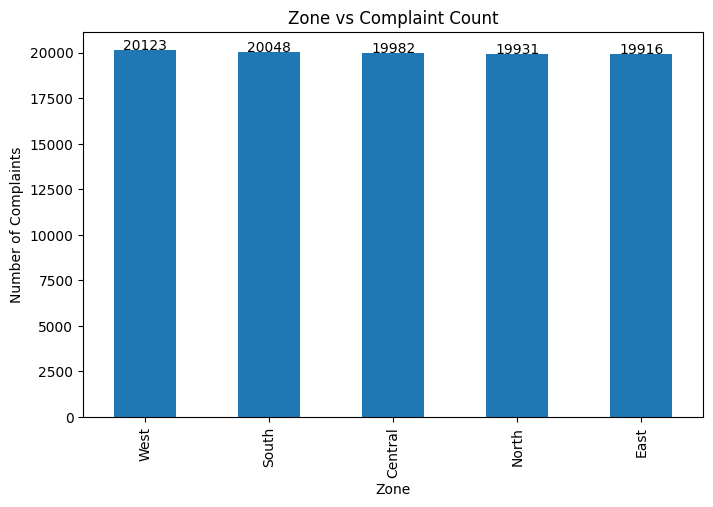

In [ ]:
#Analytics Investigation
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
zone_counts = df['Zone'].value_counts()
plt.figure(figsize=(8,5))
ax = zone_counts.plot(kind='bar')
plt.title('Zone vs Complaint Count')
plt.xlabel('Zone')
plt.ylabel('Number of Complaints')
for i, v in enumerate(zone_counts.values):
    ax.text(i, v + 20, str(v), ha='center')
plt.show()

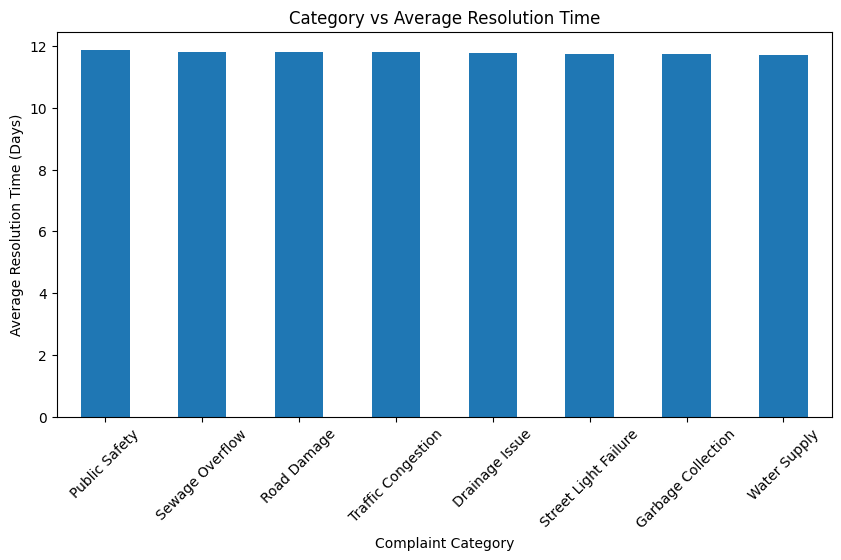

In [ ]:
category_resolution = (
    df.groupby('Category')['Resolution_Delay']
    .mean()
    .sort_values(ascending=False)
)
plt.figure(figsize=(10,5))
category_resolution.plot(kind='bar')
plt.title('Category vs Average Resolution Time')
plt.xlabel('Complaint Category')
plt.ylabel('Average Resolution Time (Days)')
plt.xticks(rotation=45)
plt.show()

In [ ]:
category_resolution = (
    df.groupby('Category')['Resolution_Delay']
    .mean()
    .sort_values(ascending=False)
)

print(category_resolution)

Category
Public Safety           11.868685
Sewage Overflow         11.811242
Road Damage             11.802637
Traffic Congestion      11.790865
Drainage Issue          11.787554
Street Light Failure    11.747210
Garbage Collection      11.744365
Water Supply            11.714349
Name: Resolution_Delay, dtype: float64


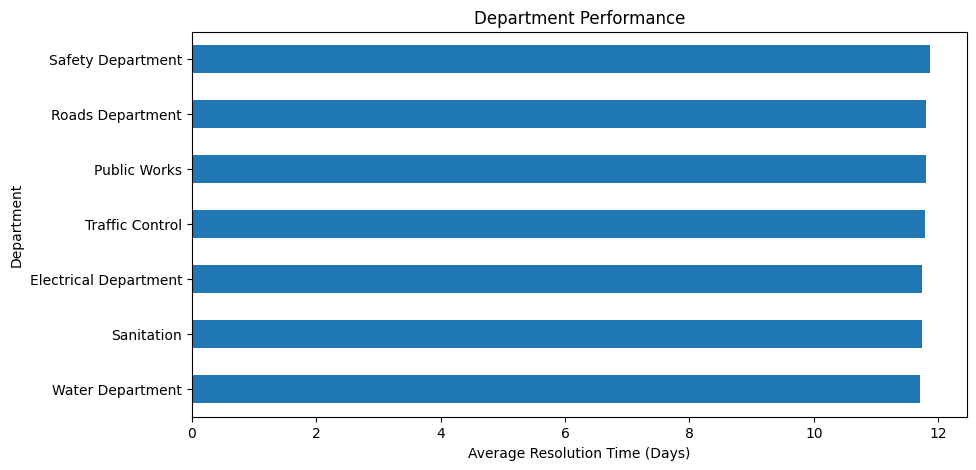

In [ ]:
department_performance = (
    df.groupby('Department')['Resolution_Delay']
    .mean()
    .sort_values()
)
plt.figure(figsize=(10,5))
department_performance.plot(kind='barh')
plt.title('Department Performance')
plt.xlabel('Average Resolution Time (Days)')
plt.ylabel('Department')
plt.show()

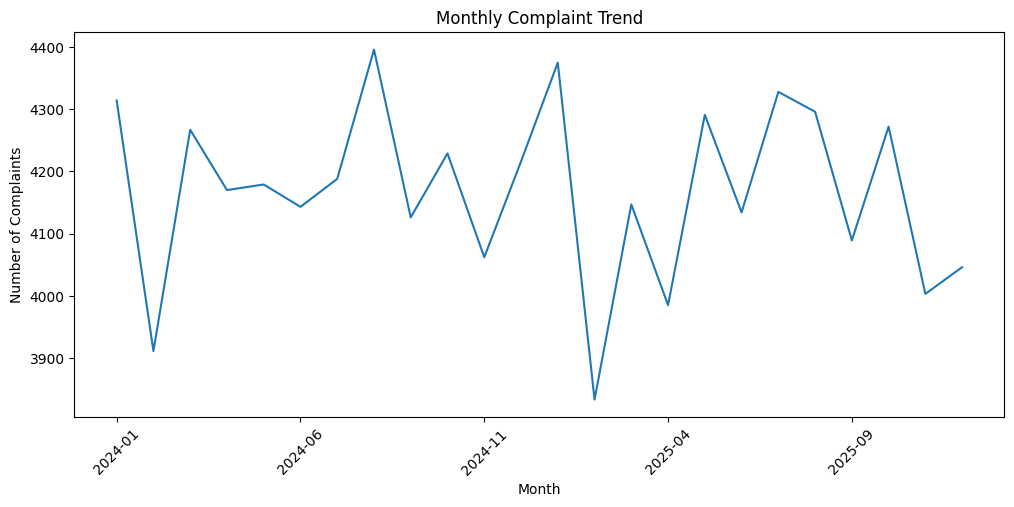

In [ ]:
monthly_trend = (
    df.groupby(
        df['Complaint_Date'].dt.to_period('M')
    ).size()
)
monthly_trend.index = monthly_trend.index.astype(str)
plt.figure(figsize=(12,5))
monthly_trend.plot()
plt.title('Monthly Complaint Trend')
plt.xlabel('Month')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45)
plt.show()

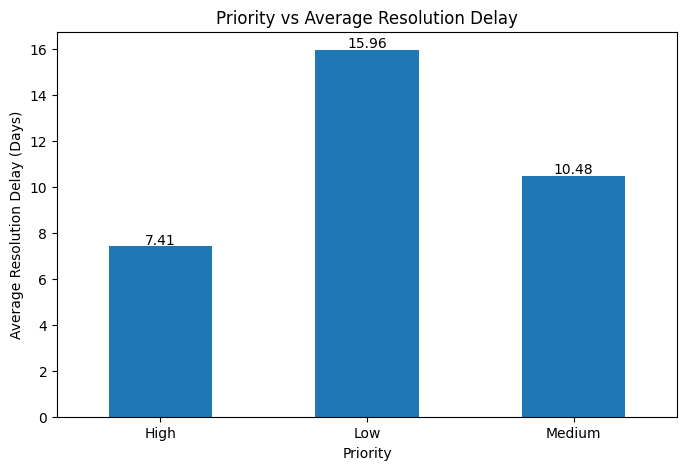

In [ ]:
priority_delay = (
    df.groupby('Priority')['Resolution_Delay']
    .mean()
)
plt.figure(figsize=(8,5))
ax = priority_delay.plot(kind='bar')
plt.title('Priority vs Average Resolution Delay')
plt.xlabel('Priority')
plt.ylabel('Average Resolution Delay (Days)')
for i, v in enumerate(priority_delay.values):
    ax.text(i, v + 0.1, f'{v:.2f}', ha='center')
plt.xticks(rotation=0)
plt.show()

In [ ]:
print("="*40)
print("SMART CITY KPI DASHBOARD")
print("="*40)
print("Total Complaints:", total_complaints)
print("Resolved Complaints:", resolved_complaints)
print("Resolution Rate:", round(resolution_rate,2), "%")
print("Average Resolution Time:", round(avg_resolution_time,2), "Days")
print("High Priority Complaints:", high_priority_complaints)
print("Citizen Satisfaction Score:", round(citizen_satisfaction,2))

SMART CITY KPI DASHBOARD
Total Complaints: 100000
Resolved Complaints: 89985
Resolution Rate: 89.98 %
Average Resolution Time: 11.78 Days
High Priority Complaints: 20137
Citizen Satisfaction Score: 3.57


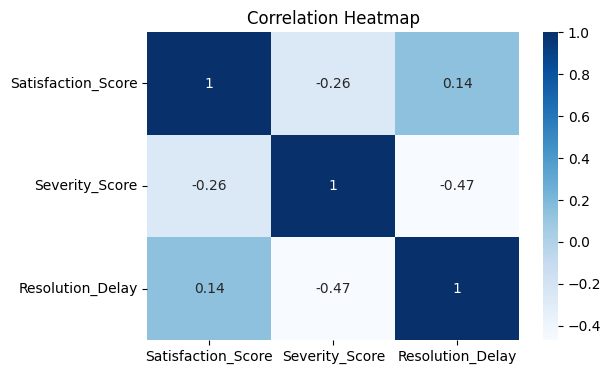

In [ ]:
numeric_cols = [
    'Satisfaction_Score',
    'Severity_Score',
    'Resolution_Delay'
]
plt.figure(figsize=(6,4))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='Blues'
)
plt.title('Correlation Heatmap')
plt.show()

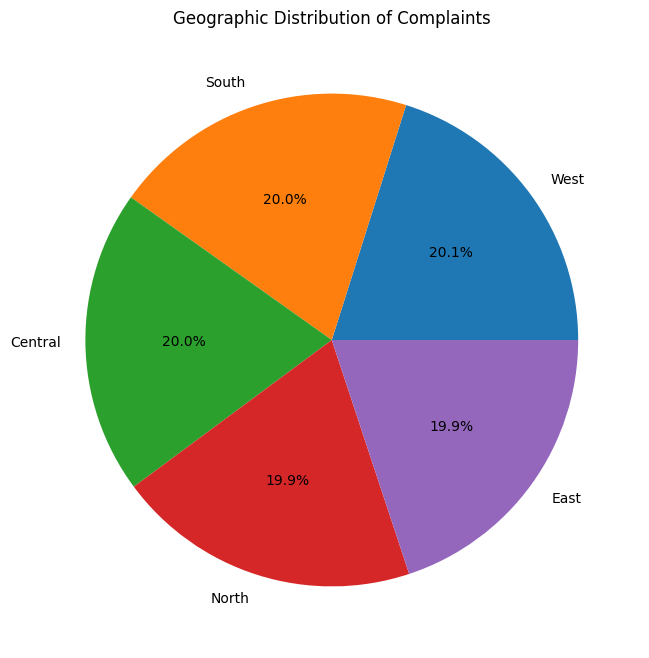

In [ ]:
#innovations
zone_counts = df['Zone'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(
    zone_counts,
    labels=zone_counts.index,
    autopct='%1.1f%%'
)
plt.title('Geographic Distribution of Complaints')
plt.show()